In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import snapatac2 as snap
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
import pyranges as pr
import os
import warnings
import requests
from importlib import reload
from umap import UMAP
from sklearn.decomposition import PCA
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cross_decomposition import CCA

from tqdm import tqdm
tqdm.pandas()

import sys
sys.path.append('/data1/normantm/multiome_collab')
from perturbseq import *
import multiome as mo

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

In [2]:
program_features = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/260414_gex_raw_100_prgm_features.csv")
adata = sc.read("/data1/normantm/eli/scratch/shao26_RPE_atlas/shao26_retina_566k.h5ad")
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)

<Figure size 500x400 with 0 Axes>

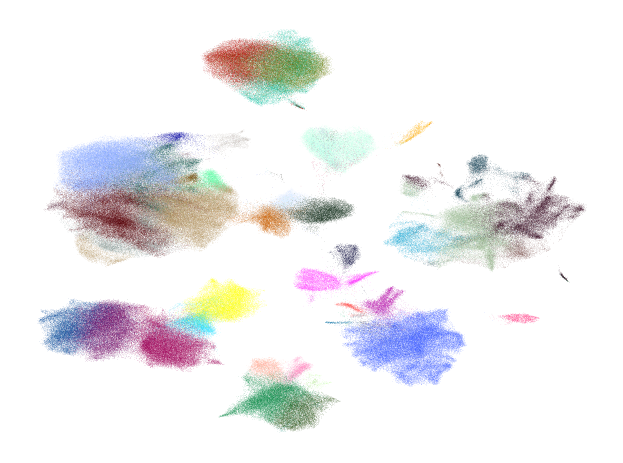

In [14]:
plt.figure(figsize = (5,4))
sc.pl.umap(adata, color = 'author_cell_type', legend_loc = None, frameon = False, title = '', show = False)
plt.tight_layout()
plt.savefig("Sx_atlas_umap_all.png", dpi = 500)
plt.show()

<Figure size 800x400 with 0 Axes>

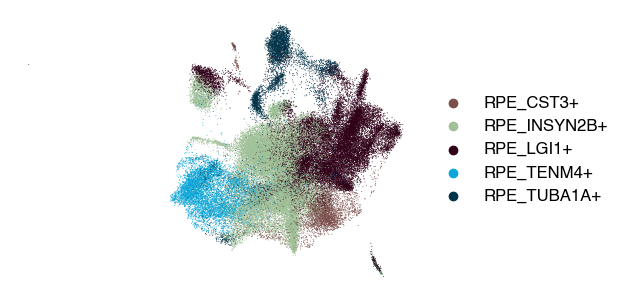

In [18]:
plt.figure(figsize = (8,4))
ax = sc.pl.umap(adata[adata.obs.author_cell_type.str.contains('RPE')], color = 'author_cell_type', frameon = False, title = '', show = False)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("Sx_atlas_umap_RPE.png", dpi = 500)
plt.show()

In [3]:
adata[adata.obs.author_cell_type.str.contains('RPE')]

View of AnnData object with n_obs × n_vars = 69244 × 35475
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage--cell_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'sample_collection_year', 'suspension_derivation_process', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type--cell_ontology_term_id', 'author_cell_type', 'cell_state', 'disease_ontology_term_id', 'reported_diseases', 'sex--cell_ontology_term_id', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Study', 'Developmental', 'Post_mortemtime', 'PMT_in_hrs', 'Eye', 'Region', 'sampleid', 'majorclass', 'cell_type', 'a

In [4]:
from sklearn.cluster import KMeans
adata.obs['km5k_metacell'] = KMeans(n_clusters = 5000, random_state = 42).fit_predict(adata.obsm['X_scVI'])

In [ ]:
sc.pp.highly_variable_genes(adata)
adata_hvg = adata[:, adata.var['highly_variable']].copy()
adata_hvg.var.index = adata_hvg.var.feature_name

sc.tl.rank_genes_groups(
    adata_hvg,
    groupby='author_cell_type',
    method='wilcoxon',
    use_raw = False
)

df_markers = sc.get.rank_genes_groups_df(adata_hvg, group = None).query("pvals_adj < 0.1 and logfoldchanges > 0")

In [7]:
adata.write_h5ad('intermediate_files/shao_atlas_metacells_markers.h5ad')

In [2]:
adata = sc.read('intermediate_files/shao_atlas_metacells_markers.h5ad')

In [3]:
sc.pp.highly_variable_genes(adata)
adata_hvg = adata[:, adata.var['highly_variable']].copy()
adata_hvg.var.index = adata_hvg.var.feature_name
sc.tl.rank_genes_groups(
    adata_hvg,
    groupby='author_cell_type',
    method='wilcoxon',
    use_raw = False
)

/data1/normantm/eli/mamba/miniforge3/envs/scprinter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/data1/normantm/eli/mamba/miniforge3/envs/scprinter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:440: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/data1/normantm/eli/mamba/miniforge3/envs/scprinter/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:450: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

In [4]:
gex = sc.read("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex_raw.h5ad")
meanpop = gex.to_df().join(gex.obs.guide_target).groupby('guide_target').mean().drop("NTC", axis = 0)
df_markers = sc.get.rank_genes_groups_df(adata_hvg, group = None).query("pvals_adj < 0.1 and logfoldchanges > 0")

states = adata.obs.query("author_cell_type.str.contains('RPE')").author_cell_type.unique()
df_states = pd.DataFrame(index = meanpop.index, columns = states)
for s in states:
    df_features = df_markers.query("group == @s and names.isin(@meanpop.columns)")
    features, weights = df_features.names, df_features.scores
    state_score = meanpop[features].dot(weights.values)
    df_states.loc[:, s] = state_score
df_states = (df_states - df_states.mean()) / df_states.std()

/tmp/ipykernel_3172567/718332498.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [11]:
df_states['condition'] = df_states.index.map(lambda i: 'double' if "_" in i else 'single')
df_plot = df_states.reset_index().melt(id_vars = ['guide_target', 'condition'], var_name = 'state', value_name = 'score')

In [19]:
from scipy.stats import levene, false_discovery_control
ps = []
for i in df_states.columns:
    if i != 'condition':
        print(i)
        ps.append(levene(df_states.query("condition == 'single'")[i], df_states.query("condition == 'double'")[i]).pvalue)
false_discovery_control(ps)

RPE_INSYN2B+
RPE_TENM4+
RPE_LGI1+
RPE_TUBA1A+
RPE_CST3+


array([0.01248512, 0.003599  , 0.00815282, 0.02191048, 0.04174949])

In [13]:
from scipy.stats import levene, false_discovery_control, mannwhitneyu, ttest_ind
ps = []
for i in df_states.columns:
    if i != 'condition':
        print(i)
        ps.append(ttest_ind(df_states.query("condition == 'single'")[i].astype(np.float64), df_states.query("condition == 'double'")[i].astype(np.float64)).pvalue)
false_discovery_control(ps)

RPE_INSYN2B+
RPE_TENM4+
RPE_LGI1+
RPE_TUBA1A+
RPE_CST3+


array([0.18847222, 0.18847222, 0.47580306, 0.47580306, 0.47580306])

2026-08-05 12:32:23 - INFO - maxp pruned
2026-08-05 12:32:23 - INFO - cmap pruned
2026-08-05 12:32:23 - INFO - post pruned
2026-08-05 12:32:23 - INFO - FFTM dropped
2026-08-05 12:32:23 - INFO - GPOS pruned
2026-08-05 12:32:23 - INFO - GSUB pruned
2026-08-05 12:32:23 - INFO - glyf pruned
2026-08-05 12:32:23 - INFO - Added gid0 to subset
2026-08-05 12:32:23 - INFO - Added first four glyphs to subset
2026-08-05 12:32:23 - INFO - Closing glyph list over 'GSUB': 51 glyphs before
2026-08-05 12:32:23 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'E', 'G', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'Y', 'Z', 'a', 'c', 'd', 'e', 'f', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'plus', 'r', 's', 'space', 't', 'three', 'two', 'underscore', 'uni0008', 'w', 'x', 'z', 'zero']
2026-08-05 12:32:23 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 13, 14, 16, 18, 21, 22, 23, 24, 25, 38, 39, 40, 42, 44, 46, 49, 50, 51, 53, 55, 56

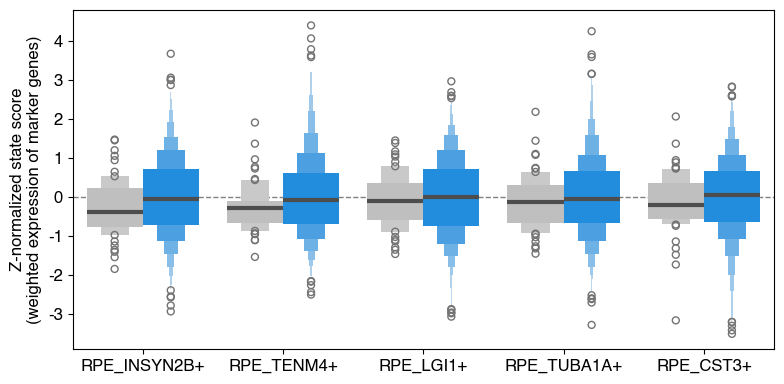

In [ ]:
plt.figure(figsize = (8,4))
sns.boxenplot(df_plot, x = 'state', y = 'score', hue = 'condition', palette = ['#bfbfbf', '#0390fc'], edgecolor = None, legend = None, line_kws={'linewidth': 3})
plt.xlabel("")
plt.ylabel("Z-normalized state score\n(weighted expression of marker genes)")
plt.axhline(y = 0, color = 'grey', linewidth = 1, linestyle = '--', zorder = 0)
plt.tight_layout()
plt.savefig("plots/Sx_atlas_state_scores.pdf")
plt.show()

In [75]:
ncells_dict = gex.obs.guide_target.value_counts().to_frame('ncells').map(np.log10).to_dict()['ncells']
avg_scores = df_states.drop('condition', axis = 1).abs().mean(axis = 1).to_frame('avg_score')
avg_scores['ncells'] = df_states.index.map(ncells_dict)
avg_scores.corr()

,avg_score,ncells
avg_score,1.000000,-0.008678
ncells,-0.008678,1.000000


In [21]:
def screen_state(ab):
    a, b = ab.split('_')
    return df_states.loc[[a, b, ab], :]

def plot_state(ab, state, df_scores):
    
    a, b = ab.split('_')
    sns.clustermap(
        meanpop.loc[[a, b, ab], df_markers.query("group == @state and scores > 0 and names.isin(@meanpop.columns)").names.values],
        cmap="RdBu_r", 
        center=0,
        vmax = 0.5,
        vmin = -0.5,
        row_cluster=False,
        robust=True,
        figsize=(6, 2.25),
        xticklabels = 0,
        # row_colors = df_scores
    )

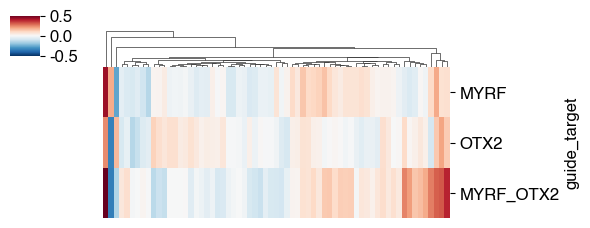

In [27]:
plot_state("MYRF_OTX2", "RPE_LGI1+", df_scores.drop('RPE_LGI1+', axis = 1))

2026-08-05 13:53:48 - INFO - maxp pruned
2026-08-05 13:53:48 - INFO - cmap pruned
2026-08-05 13:53:48 - INFO - post pruned
2026-08-05 13:53:48 - INFO - FFTM dropped
2026-08-05 13:53:48 - INFO - GPOS pruned
2026-08-05 13:53:48 - INFO - GSUB pruned
2026-08-05 13:53:48 - INFO - glyf pruned
2026-08-05 13:53:48 - INFO - Added gid0 to subset
2026-08-05 13:53:48 - INFO - Added first four glyphs to subset
2026-08-05 13:53:48 - INFO - Closing glyph list over 'GSUB': 28 glyphs before
2026-08-05 13:53:48 - INFO - Glyph names: ['.notdef', '.null', 'F', 'M', 'O', 'P', 'R', 'X', 'Y', 'a', 'c', 'd', 'e', 'five', 'g', 'hyphen', 'i', 'l', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 't', 'u', 'underscore', 'uni0008', 'zero']
2026-08-05 13:53:48 - INFO - Glyph IDs:   [0, 1, 2, 3, 18, 19, 21, 22, 26, 43, 50, 52, 53, 55, 61, 62, 68, 70, 72, 73, 74, 76, 78, 81, 84, 87, 89, 90]
2026-08-05 13:53:48 - INFO - Closed glyph list over 'GSUB': 28 glyphs after
2026-08-05 13:53:48 - INFO - Glyph names: ['.notdef',

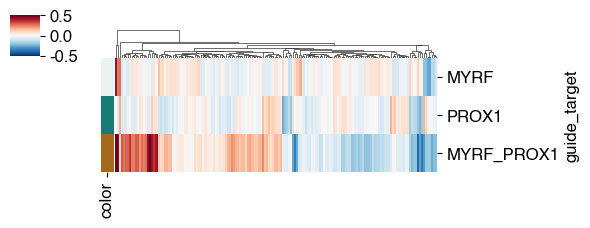

In [208]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cmap = plt.get_cmap("BrBG_r")
norm = mcolors.Normalize(vmin=-1, vmax=1)
df_scores = screen_state("MYRF_PROX1")[['RPE_CST3+']]
df_scores['color'] = df_scores['RPE_CST3+'].apply(lambda x: cmap(norm(x)))
plot_state("MYRF_PROX1", "RPE_CST3+", df_scores.drop('RPE_CST3+', axis = 1))
plt.savefig("plots/Sx_atlas_MYRF_PROX1_CST3+.pdf")

2026-08-05 13:57:57 - INFO - maxp pruned
2026-08-05 13:57:57 - INFO - cmap pruned
2026-08-05 13:57:57 - INFO - post pruned
2026-08-05 13:57:57 - INFO - FFTM dropped
2026-08-05 13:57:57 - INFO - GPOS pruned
2026-08-05 13:57:57 - INFO - GSUB pruned
2026-08-05 13:57:57 - INFO - glyf pruned
2026-08-05 13:57:57 - INFO - Added gid0 to subset
2026-08-05 13:57:57 - INFO - Added first four glyphs to subset
2026-08-05 13:57:57 - INFO - Closing glyph list over 'GSUB': 28 glyphs before
2026-08-05 13:57:57 - INFO - Glyph names: ['.notdef', '.null', 'A', 'F', 'M', 'O', 'R', 'X', 'Y', 'a', 'c', 'd', 'e', 'five', 'g', 'hyphen', 'i', 'l', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 't', 'u', 'underscore', 'uni0008', 'zero']
2026-08-05 13:57:57 - INFO - Glyph IDs:   [0, 1, 2, 3, 18, 19, 21, 22, 26, 38, 43, 50, 52, 55, 61, 62, 68, 70, 72, 73, 74, 76, 78, 81, 84, 87, 89, 90]
2026-08-05 13:57:57 - INFO - Closed glyph list over 'GSUB': 28 glyphs after
2026-08-05 13:57:57 - INFO - Glyph names: ['.notdef',

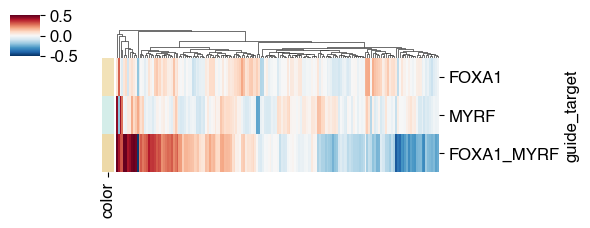

In [212]:
df_scores = screen_state("FOXA1_MYRF")[['RPE_INSYN2B+']]
df_scores['color'] = df_scores['RPE_INSYN2B+'].apply(lambda x: cmap(norm(x)))
plot_state("FOXA1_MYRF", "RPE_INSYN2B+", df_scores.drop('RPE_INSYN2B+', axis = 1))
plt.savefig("plots/Sx_atlas_FOXA1_MYRF_INSYN2B+.pdf")

2026-08-05 13:58:41 - INFO - maxp pruned
2026-08-05 13:58:41 - INFO - cmap pruned
2026-08-05 13:58:41 - INFO - post pruned
2026-08-05 13:58:41 - INFO - FFTM dropped
2026-08-05 13:58:41 - INFO - GPOS pruned
2026-08-05 13:58:41 - INFO - GSUB pruned
2026-08-05 13:58:41 - INFO - glyf pruned
2026-08-05 13:58:41 - INFO - Added gid0 to subset
2026-08-05 13:58:41 - INFO - Added first four glyphs to subset
2026-08-05 13:58:41 - INFO - Closing glyph list over 'GSUB': 26 glyphs before
2026-08-05 13:58:41 - INFO - Glyph names: ['.notdef', '.null', 'C', 'F', 'M', 'R', 'X', 'Y', 'a', 'c', 'd', 'e', 'five', 'g', 'hyphen', 'i', 'l', 'nonmarkingreturn', 'o', 'period', 'r', 't', 'u', 'underscore', 'uni0008', 'zero']
2026-08-05 13:58:41 - INFO - Glyph IDs:   [0, 1, 2, 3, 18, 19, 21, 26, 40, 43, 50, 55, 61, 62, 68, 70, 72, 73, 74, 76, 78, 81, 84, 87, 89, 90]
2026-08-05 13:58:41 - INFO - Closed glyph list over 'GSUB': 26 glyphs after
2026-08-05 13:58:41 - INFO - Glyph names: ['.notdef', '.null', 'C', 'F', 

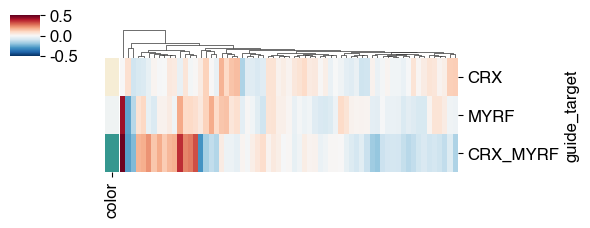

In [214]:
df_scores = screen_state("CRX_MYRF")[['RPE_LGI1+']]
df_scores['color'] = df_scores['RPE_LGI1+'].apply(lambda x: cmap(norm(x)))
plot_state("CRX_MYRF", "RPE_LGI1+", df_scores.drop('RPE_LGI1+', axis = 1))
plt.savefig("plots/Sx_atlas_CRX_MYRF_LGI+.pdf")

In [176]:
tfs = pd.read_excel("/data1/normantm/eli/scratch/TableS4_guides.xlsx").target_gene.unique()
adata.var.index = adata.var.feature_name
tf_expr = sc.get.aggregate(adata[:, adata.var.index.isin(tfs)], by = 'km5k_metacell', func = 'mean')
df_tfs = pd.DataFrame(tf_expr.layers['mean'], index = tf_expr.obs_names, columns = tf_expr.var_names)

In [216]:
df_tfs[['FOXA1', 'PROX1', 'CRX', 'MYRF']].corr()

feature_name,FOXA1,PROX1,CRX,MYRF
feature_name,,,,
FOXA1,1.000000,0.002066,-0.014561,-0.014936
PROX1,0.002066,1.000000,0.238651,0.217020
CRX,-0.014561,0.238651,1.000000,0.940092
MYRF,-0.014936,0.217020,0.940092,1.000000


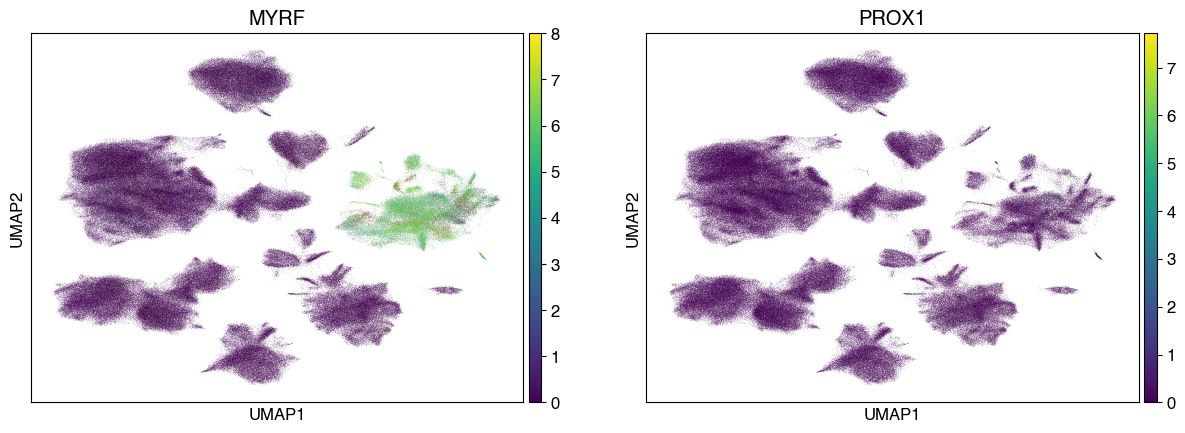

In [229]:
sc.pl.umap(adata, use_raw = False, color = ['MYRF', 'PROX1'])

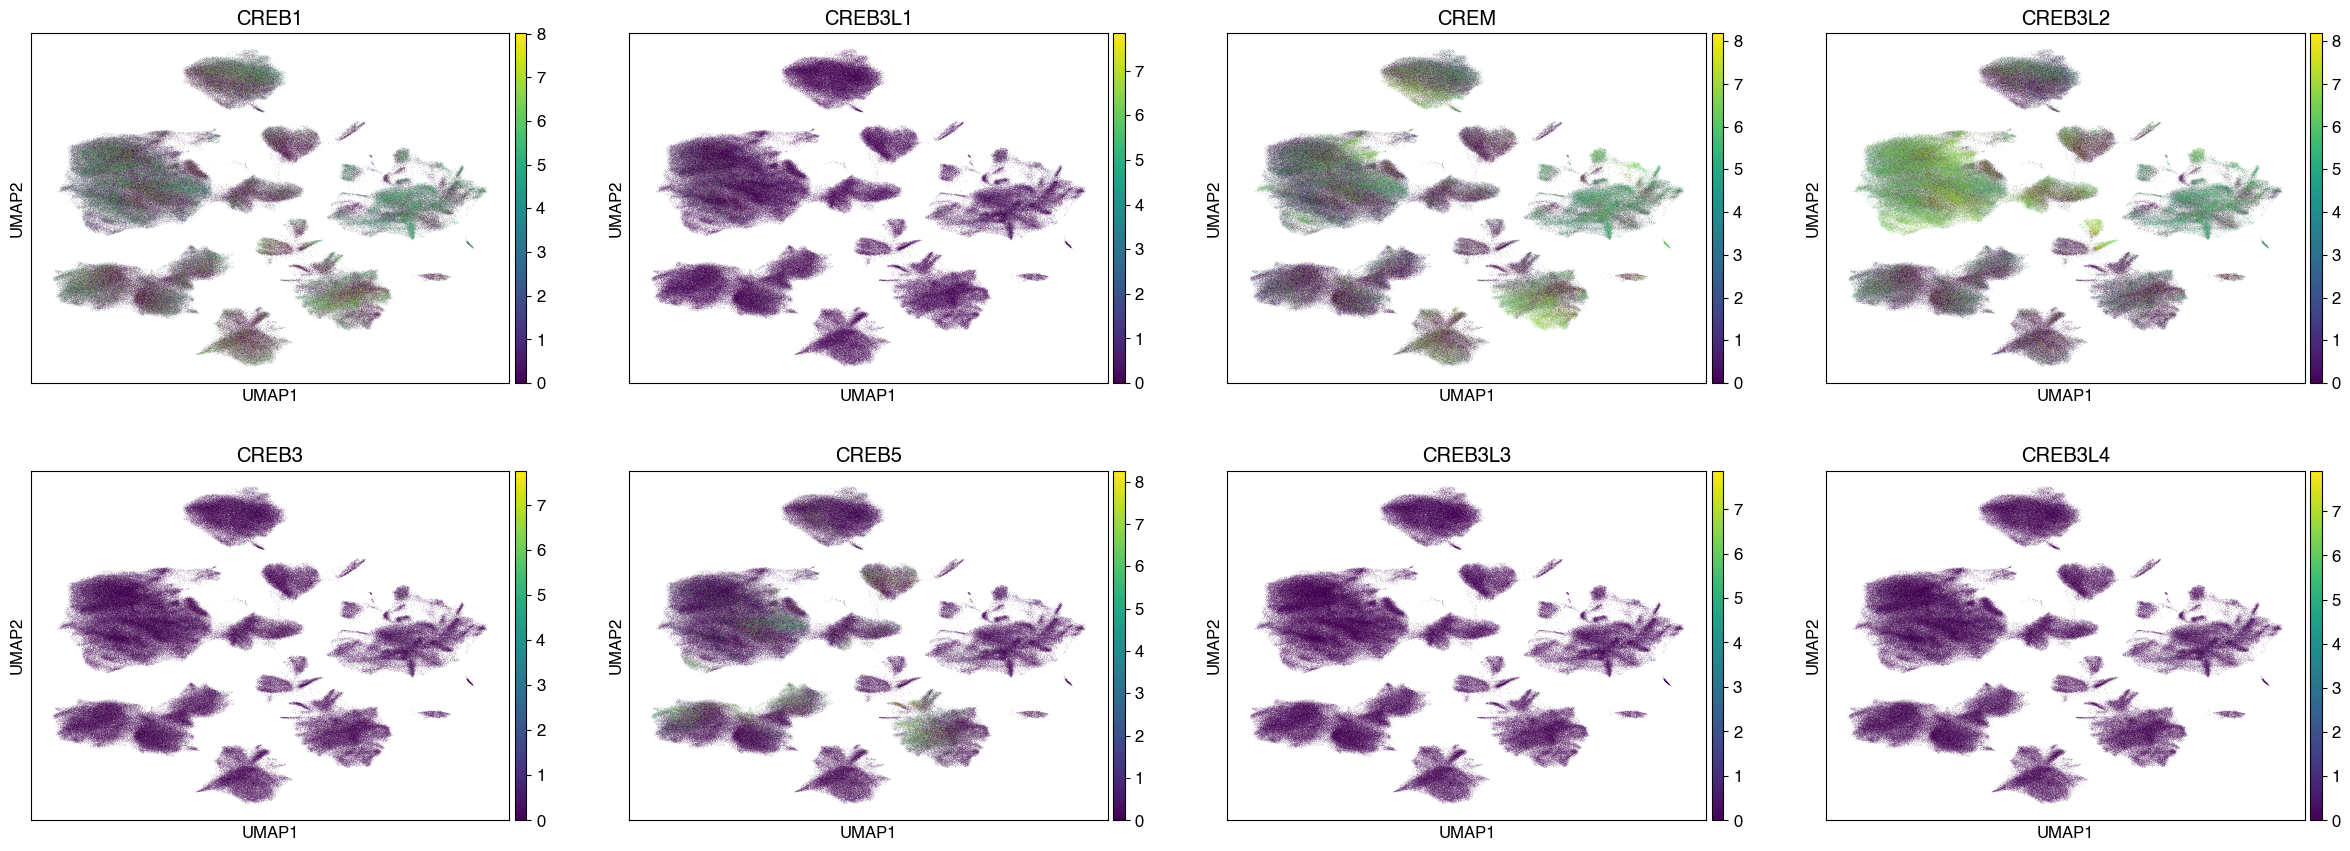

In [ ]:
# adata.var.index = adata.var.gene_names
sc.pl.umap(adata, use_raw = False, color = ['CREB1', 'CREB3L1', 'CREM', 'CREB3L2', 'CREB3', 'CREB5', 'CREB3L3', 'CREB3L4'])